## Plotting the results of the paramPID track/shower classification

In [12]:
import matplotlib.pyplot as plt
import pylab as pl
import h5py
from astropy.table import Table
import numpy as np

path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/PID_output_arca.h5"
path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/pid_histdata_track_score_0.5.h5"
###############

with h5py.File(path, 'r') as h5_file:
    #table = Table.read(h5_file)
    #print(table)
    print(h5_file)
    for key in h5_file.keys():
        print(key)

    eCC = h5_file['eCC']
    muCC = h5_file['muCC']
    muNC = h5_file['muNC']
    tauCC = h5_file['tauCC']


<HDF5 file "pid_histdata_track_score_0.5.h5" (mode r)>
bins
eCC
muCC
muNC
tauCC


In [2]:
import h5py

path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/PID_output_arca.h5"

with h5py.File(path, 'r') as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

summary
summary/_i_table
summary/_i_table/index
summary/_i_table/index/abounds
summary/_i_table/index/bounds
summary/_i_table/index/indices
summary/_i_table/index/indicesLR
summary/_i_table/index/mbounds
summary/_i_table/index/mranges
summary/_i_table/index/ranges
summary/_i_table/index/sorted
summary/_i_table/index/sortedLR
summary/_i_table/index/zbounds
summary/table


In [ ]:
import h5py
import numpy as np

path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/PID_output_arca.h5"

with h5py.File(path, 'r') as f:
    features = f['features'][:]  # shape (n_samples, n_features)
    labels = f['labels'][:]      # shape (n_samples,)
    predictions = f['predictions'][:]  # optional
    feature_names = [name.decode('utf-8') for name in f['feature_names'][:]]


KeyError: "Unable to synchronously open object (object 'features' doesn't exist)"

In [5]:
import tables
import pandas as pd

path = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/PID_output_arca.h5"

with tables.open_file(path, mode='r') as h5file:
    table = h5file.get_node('/summary/table')
    print(table)  # View structure
    print(table.colnames)  # List of all columns

    # Convert to pandas DataFrame
    df = pd.DataFrame.from_records(table.read())

print(df.head())
print(df.columns)


/summary/table (Table(871341,)) ''
['index', 'values_block_0', 'values_block_1', 'values_block_2', 'values_block_3']


ValueError: Per-column arrays must each be 1-dimensional

In [48]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_pid_from_hdf5(
    filename,
    score_name="score",
    cut_value=0.5,
    energy_range=(10, 1e6),
    plot_hist=True,
    plot_eff=True,
    save_plots=True,
    show_plots=False,
    log_scale=True,
    yscale="log",
    legend_loc="best",
    output_prefix="pid",
    style_dict=None,
    detector="ARCA"
):
    """
    Plots PID histograms and efficiencies from an HDF5 histogram file.

    Parameters:
    - filename (str): HDF5 file with histogram data.
    - score_name (str): Name of the score variable (used for axes/labels).
    - cut_value (float): Cut value to draw as vertical line.
    - energy_range (tuple): (EMIN, EMAX) for energy plots.
    - plot_hist (bool): Whether to plot score distributions.
    - plot_eff (bool): Whether to plot energy efficiency curves.
    - save_plots (bool): Save plots to files.
    - show_plots (bool): Show plots interactively.
    - log_scale (bool): Use log scale on energy x-axis.
    - yscale (str): y-axis scale for histograms ('log', 'linear', etc.).
    - legend_loc (str): Where to place the legend.
    - output_prefix (str): Filename prefix.
    - style_dict (dict): Dictionary with styling options for each category.
    """

    # Default styling if none provided
    if style_dict is None:
        style_dict = {
            "muCC": {"color": "blue", "linestyle": "-", "label": "muCC"},
            "eCC": {"color": "red", "linestyle": "-", "label": "eCC"},
            "muNC": {"color": "blue", "linestyle": "--", "label": "muNC"},
            "eNC": {"color": "red", "linestyle": "--", "label": "eNC"},
            "tauCC": {"color": "green", "linestyle": "-", "label": "tauCC"},
        }

    with h5py.File(filename, "r") as f:
        bins = np.array(f["bins"])
        available_keys = list(f.keys())
        categories = [key for key in available_keys if key != "bins"]

        if plot_hist:
            plt.figure()
            for cat in categories:
                if cat not in style_dict:
                    # Skip categories without style instead of plotting them
                    continue
                style = style_dict[cat]
                values = np.array(f[cat])
                bin_centers = (bins[:-1] + bins[1:]) / 2
                # Extend x and y for zero drop at edges
                x = np.concatenate(([bins[0]], bin_centers, [bins[-1]]))
                y = np.concatenate(([0], values, [0]))

                plt.plot(x, y, drawstyle="steps-mid", **style)



                # plt.step(bins[:-1], values, where="post", **style)  # Step plot with vertical edges
                # plt.vlines([bins[0], bins[-2]], ymin=0, ymax=[values[0], values[-1]], 
                        #colors=style.get("color", "black"), linestyles=style.get("linestyle", "-"), alpha=0.7)


            plt.axvline(cut_value, color="black", linestyle="--", label=f"Cut Value: {cut_value}")
            plt.xlabel(score_name)
            plt.ylabel("Density")
            plt.title(f"Track Score Distribution of Classified {detector} MC Files")
            plt.yscale(yscale)
            plt.legend(loc=legend_loc)
            plt.grid(True, alpha=0.6)
            if save_plots:
                plt.savefig(f"{output_prefix}_{score_name}_cut_{cut_value}_hist.png")
            if show_plots:
                plt.show()
            plt.close()

        if plot_eff:
            logbins = np.logspace(np.log10(energy_range[0]), np.log10(energy_range[1]), 40)
            bin_centers = logbins[:-1]  # Will need actual efficiency data for real plotting

            plt.figure()
            for cat in categories:
                # In real usage, you'll read energy-binned efficiency from a different source
                # Here we just plot dummy constant lines for visual structure
                style = style_dict.get(cat, {"label": cat})
                dummy_eff = np.random.uniform(0.5, 1.0, len(logbins) - 1)
                plt.plot(bin_centers, dummy_eff, drawstyle="steps-mid", **style)

            plt.xlabel("Energy [GeV]")
            plt.ylabel("Efficiency (placeholder)")
            plt.title("Classification Efficiency")
            plt.xscale("log" if log_scale else "linear")
            plt.ylim(0, 1.01)
            plt.xlim(energy_range)
            plt.grid(True, which='both', linestyle='dotted')
            plt.legend(loc=legend_loc)
            if save_plots:
                plt.savefig(f"{output_prefix}_eff_cut_{cut_value}.png")
            if show_plots:
                plt.show()
            plt.close()


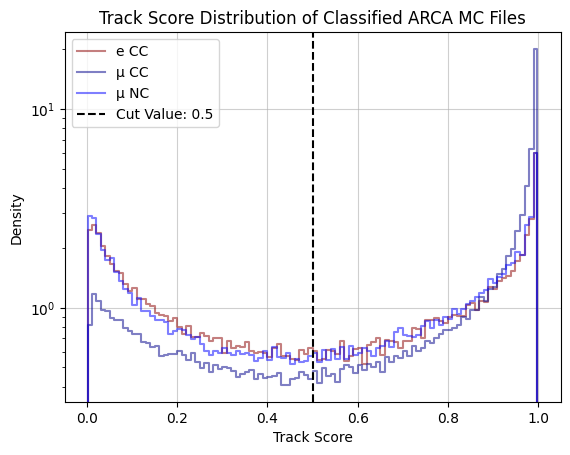

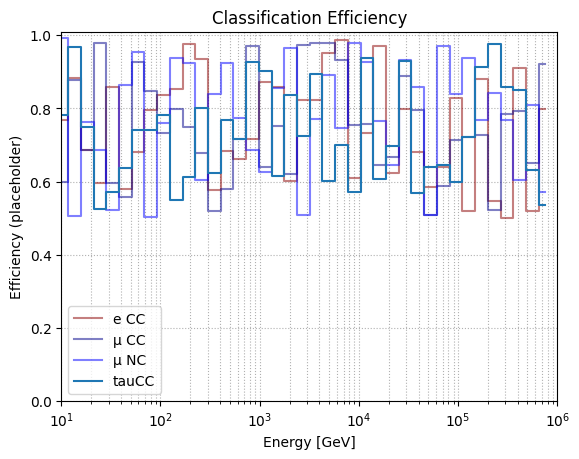

In [49]:
alpha = 0.5
plot_pid_from_hdf5(
    filename="/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/pid_histdata_track_score_0.5.h5",
    score_name="Track Score",
    cut_value=0.5,
    energy_range=(10, 1e6),
    show_plots=True,
    style_dict={
        "muCC": {"color": "darkblue", "linestyle": "-", "label": "μ CC", "alpha": alpha},
        "eCC": {"color": "darkred", "linestyle": "-", "label": "e CC", "alpha": alpha},
        "muNC": {"color": "blue", "linestyle": "-", "label": "μ NC", "alpha": alpha},
        "eNC": {"color": "darkred", "linestyle": "--", "label": "e NC", "alpha": alpha},
        #"tauCC": {"color": "forestgreen", "linestyle": "-", "label": "τ CC", "alpha": alpha},
    }
)


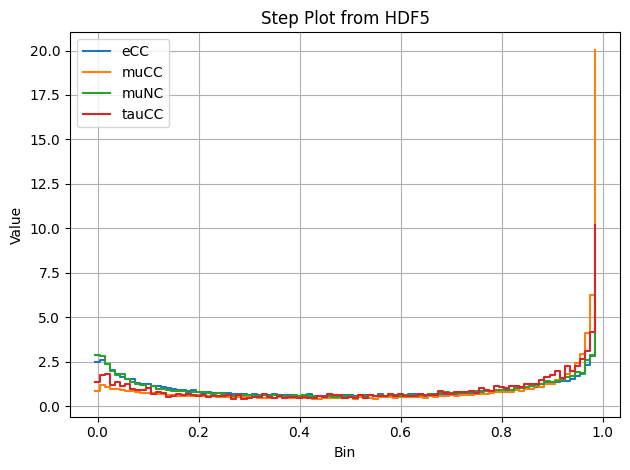

In [28]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = "/home/hpc/capn/capn107h/software/nextflow_output/parampid/trained_rdfiles/pid_histdata_track_score_0.5.h5"

with h5py.File(filename, "r") as f:
    bins = np.array(f["bins"])  # these are assumed to be bin centers
    available_keys = list(f.keys())
    categories = [key for key in available_keys if key != "bins"]
    
    # Width between bin centers
    bin_widths = np.diff(bins)
    # Assume constant width if only one bin or evenly spaced bins
    if len(bin_widths) == 0:
        bin_width = 1.0  # fallback
    elif np.allclose(bin_widths, bin_widths[0]):
        bin_width = bin_widths[0]
    else:
        # Variable bin widths; estimate edges manually
        bin_width = None

    # Estimate bin edges
    if bin_width is not None:
        edges = np.concatenate([
            [bins[0] - bin_width / 2],
            bins[:-1] + bin_width / 2,
            [bins[-1] + bin_width / 2]
        ])
    else:
        # Midpoints between bin centers to get edges
        midpoints = (bins[:-1] + bins[1:]) / 2
        edges = np.concatenate([[bins[0] - (midpoints[0] - bins[0])], midpoints, [bins[-1] + (bins[-1] - midpoints[-1])]])

        # Plot each category
    for key in categories:
        values = np.array(f[key])
        
        # Plot using left edges only; values are assumed to be per bin
        plt.step(edges[:-2], values, where="post", label=key)


plt.xlabel("Bin")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.title("Step Plot from HDF5")
plt.tight_layout()
plt.show()
